## 一，准备数据

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# df = pd.read_csv("./eat_pytorch_datasets/covid-19.csv",sep = "\t")
# df = pd.read_csv("E:\AIMS\第四章：LSTM时间序列预测任务\Time-Series-stock--stove-6-1-flow\data\MQLL1-noid_train.csv")

# macOS data load
df = pd.read_csv("MQLL1-noid_train.csv")

/var/folders/mg/50rhj31j7m955hzvnjqw0w1m0000gn/T/ipykernel_95626/3529092366.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MQLL1-noid_train.csv")


In [3]:
df.describe()

,MQLL1,KQLL1,GDWD1,YDWD1,RZ,RSZ1
count,412345.000000,412345.000000,412345.000000,412345.000000,412345.000000,412345.000000
mean,18058.049971,15131.267226,1257.219289,255.463774,3203.382915,0.594653
std,15135.104726,12597.311041,43.452070,73.128626,334.904010,0.490960
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1234.691000,181.000000,3169.831000,0.000000
50%,29147.633000,24860.061000,1270.364000,247.103000,3230.382000,1.000000
75%,31244.650000,25859.577000,1289.212000,318.140000,3299.974000,1.000000
max,39976.039000,33037.754000,1583.294000,814.500000,3915.398000,1.000000


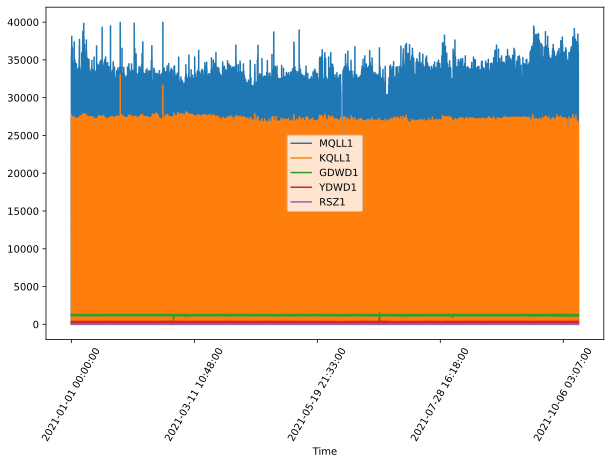

In [4]:
df.plot(x = "Time",y = ["MQLL1","KQLL1","GDWD1", "YDWD1","RSZ1"],figsize=(10,6))
plt.xticks(rotation=60);

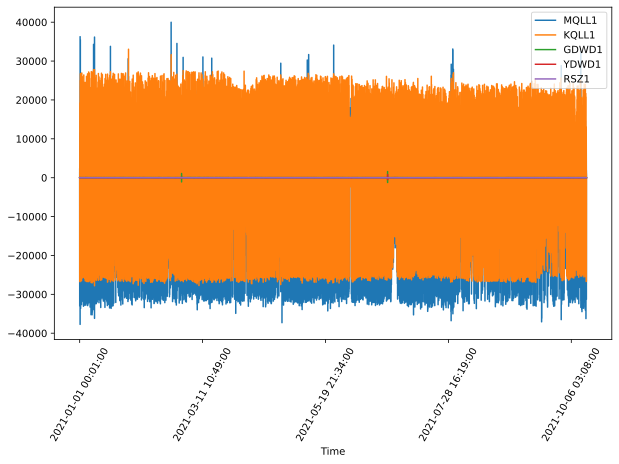

In [5]:
dfdata = df.set_index("Time")
dfdiff = dfdata.diff(periods=1).dropna()
dfdiff = dfdiff.reset_index("Time")

dfdiff.plot(x = "Time",y = ["MQLL1","KQLL1","GDWD1", "YDWD1","RSZ1"],figsize=(10,6))
plt.xticks(rotation=60)
dfdiff = dfdiff.drop("Time",axis = 1).astype("float32")

In [6]:
dfdiff.head()

,MQLL1,KQLL1,GDWD1,YDWD1,RZ,RSZ1
0,1235.593994,18.601999,0.0,2.0,7.364,0.0
1,-1981.906982,-38.667999,-1.0,2.0,7.890,0.0
2,1825.038940,14.404000,-3.0,2.0,4.208,0.0
3,-750.562012,-39.306999,1.0,2.0,-0.263,0.0
4,-621.296997,4.922000,-3.0,2.0,-1.841,0.0


下面我们通过继承torch.utils.data.Dataset实现自定义时间序列数据集。

torch.utils.data.Dataset是一个抽象类，用户想要加载自定义的数据只需要继承这个类，并且覆写其中的两个方法即可：

* `__len__`:实现len(dataset)返回整个数据集的大小。
* `__getitem__`:用来获取一些索引的数据，使`dataset[i]`返回数据集中第i个样本。

不覆写这两个方法会直接返回错误。


In [7]:
import torch 
from torch import nn 
from torch.utils.data import Dataset,DataLoader,TensorDataset


#用某日前8天窗口数据作为输入预测该日数据
WINDOW_SIZE = 8

class Covid19Dataset(Dataset):
        
    def __len__(self):
        return len(dfdiff) - WINDOW_SIZE
    
    def __getitem__(self,i):
        x = dfdiff.loc[i:i+WINDOW_SIZE-1,:]
        feature = torch.tensor(x.values)
        y = dfdiff.loc[i+WINDOW_SIZE,:]
        label = torch.tensor(y.values)
        return (feature,label)
    
ds_train = Covid19Dataset()

#数据较小，可以将全部训练数据放入到一个batch中，提升性能
dl_train = DataLoader(ds_train,batch_size = 16)

for features,labels in dl_train:
    break 
    
#dl_train同时作为验证集
dl_val = dl_train

## 二，定义模型

使用Pytorch通常有三种方式构建模型：使用nn.Sequential按层顺序构建模型，继承nn.Module基类构建自定义模型，继承nn.Module基类构建模型并辅助应用模型容器进行封装。

此处选择第二种方式构建模型。



In [8]:
import torch
from torch import nn 
import importlib 
import torchkeras 

torch.random.seed()


class Block(nn.Module):
    
    def __init__(self):
        super(Block,self).__init__()
    
    def forward(self,x,x_input):
        x_out = torch.max((1+x)*x_input[:,-1,:],torch.tensor(0.0))
        return x_out
    
class Net(nn.Module):
    
    def __init__(self):
        super(Net, self).__init__()
        # 3层lstm
        self.lstm = nn.LSTM(input_size = 6,hidden_size = 6,num_layers = 5,batch_first = True)
        self.linear = nn.Linear(6,6)
        self.block = Block()
        
    def forward(self,x_input):
        x = self.lstm(x_input)[0][:,-1,:]
        x = self.linear(x)
        y = self.block(x,x_input)
        return y
        
net = Net()
print(net)

2023-05-24 10:20:28.538715: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Net(
  (lstm): LSTM(6, 6, num_layers=5, batch_first=True)
  (linear): Linear(in_features=6, out_features=6, bias=True)
  (block): Block()
)


```
Net(
  (lstm): LSTM(3, 3, num_layers=5, batch_first=True)
  (linear): Linear(in_features=3, out_features=3, bias=True)
  (block): Block()
)
```

In [9]:
from torchkeras import summary
summary(net,input_data=features);

--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
LSTM-1                                    [-1, 8, 6]                1,680
Linear-2                                     [-1, 6]                   42
Block-3                                      [-1, 6]                    0
Total params: 1,722
Trainable params: 1,722
Non-trainable params: 0
--------------------------------------------------------------------------
Input size (MB): 0.000069
Forward/backward pass size (MB): 0.000458
Params size (MB): 0.006569
Estimated Total Size (MB): 0.007095
--------------------------------------------------------------------------


```
--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
==========================================================================
LSTM-1                                    [-1, 8, 3]                  480
Linear-2                                     [-1, 3]                   12
Block-3                                      [-1, 3]                    0
==========================================================================
Total params: 492
Trainable params: 492
Non-trainable params: 0
--------------------------------------------------------------------------
Input size (MB): 0.000069
Forward/backward pass size (MB): 0.000229
Params size (MB): 0.001877
Estimated Total Size (MB): 0.002174
--------------------------------------------------------------------------

```

### 三，训练模型

训练Pytorch通常需要用户编写自定义训练循环，训练循环的代码风格因人而异。

有3类典型的训练循环代码风格：脚本形式训练循环，函数形式训练循环，类形式训练循环。

此处介绍一种引进pytorch_lightning库实现的类形式的训练循环。

该训练循环的代码也是torchkeras库中LightModel类的核心代码。

torchkeras详情:  https://github.com/lyhue1991/torchkeras 

注：循环神经网络调试较为困难，需要设置多个不同的学习率多次尝试，以取得较好的效果。


In [10]:
import torch 
from torch import nn 
import pytorch_lightning as pl
import datetime
import sys 
import numpy as np
import pandas as pd 
from copy import deepcopy

class LightModel(pl.LightningModule):
    
    def __init__(self,net,loss_fn,metrics_dict=None,optimizer=None,lr_scheduler=None):
        super().__init__()
        self.net = net
        self.history = {}
        
        self.train_metrics = nn.ModuleDict(metrics_dict)
        self.val_metrics = deepcopy(self.train_metrics)
        self.test_metrics = deepcopy(self.train_metrics)
        
        self.loss_fn = loss_fn
        self.optimizer = optimizer if optimizer is not None else torch.optim.Adam(self.parameters(), lr=1e-2)
        self.lr_scheduler = lr_scheduler 
        
        for p in ["net","loss_fn","metrics_dict","optimizer","lr_scheduler"]:
            self.save_hyperparameters(p)
        
    def forward(self,x):
        if self.net:
            return self.net.forward(x)
        else:
            raise NotImplementedError
            
    def shared_step(self,batch,batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds,y)
        return {'loss': loss, 'preds': preds.detach(), 'y': y.detach()}
    
    def configure_optimizers(self):
        if self.lr_scheduler is None:
            return self.optimizer
        return {"optimizer":self.optimizer,"lr_scheduler":self.lr_scheduler}
    
    def training_step(self, batch, batch_idx):
        return self.shared_step(batch,batch_idx)
    
    def validation_step(self, batch, batch_idx):
        return self.shared_step(batch,batch_idx)
    
    def test_step(self, batch, batch_idx):
        return self.shared_step(batch,batch_idx)
    
    def predict_step(self, batch, batch_idx):
        if isinstance(batch,list) and len(batch)==2:
            return self(batch[0])
        else:
            return self(batch)
        
    def shared_step_end(self,outputs,stage):
        metrics = self.train_metrics if stage=="train" else (
            self.val_metrics if stage=="val" else self.test_metrics)
        for name in metrics:
            step_metric = metrics[name](outputs['preds'], outputs['y']).item()
            if stage=="train":
                self.log(name,step_metric,prog_bar=True)
        return outputs["loss"].mean()
        
    def training_step_end(self, outputs):
        return {'loss':self.shared_step_end(outputs,"train")}
            
    def validation_step_end(self, outputs):
        return {'val_loss':self.shared_step_end(outputs,"val")}
            
    def test_step_end(self, outputs):
        return {'test_loss':self.shared_step_end(outputs,"test")}
            
    def shared_epoch_end(self,outputs,stage="train"):
        metrics = self.train_metrics if stage=="train" else (
            self.val_metrics if stage=="val" else self.test_metrics)
        
        epoch = self.trainer.current_epoch
        stage_loss = torch.mean(torch.tensor([t[(stage+"_loss").replace('train_','')] for t in outputs])).item()
        dic = {"epoch":epoch,stage+"_loss":stage_loss}
        
        for name in metrics:
            epoch_metric = metrics[name].compute().item() 
            metrics[name].reset()
            dic[stage+"_"+name] = epoch_metric 
        if stage!='test':
            self.history[epoch] = dict(self.history.get(epoch,{}),**dic)    
        return dic 
    
    def training_epoch_end(self, outputs):
        dic = self.shared_epoch_end(outputs,stage="train")
        self.print(dic)
        dic.pop("epoch",None)
        self.log_dict(dic, logger=True)

    def validation_epoch_end(self, outputs):
        dic = self.shared_epoch_end(outputs,stage="val")
        self.print_bar()
        self.print(dic)
        dic.pop("epoch",None)
        self.log_dict(dic, logger=True)
        
        #log when reach best score
        ckpt_cb = self.trainer.checkpoint_callback
        monitor = ckpt_cb.monitor 
        mode = ckpt_cb.mode 
        arr_scores = self.get_history()[monitor]
        best_score_idx = np.argmax(arr_scores) if mode=="max" else np.argmin(arr_scores)
        if best_score_idx==len(arr_scores)-1:   
            self.print("<<<<<< reach best {0} : {1} >>>>>>".format(monitor,
                 arr_scores[best_score_idx]),file=sys.stderr)
    
    def test_epoch_end(self, outputs):
        dic = self.shared_epoch_end(outputs,stage="test")
        dic.pop("epoch",None)
        self.print(dic)
        self.log_dict(dic, logger=True)
        
    def get_history(self):
        return pd.DataFrame(self.history.values()) 
    
    def print_bar(self): 
        nowtime = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        self.print("\n"+"="*80 + "%s"%nowtime) 

In [11]:
from torchmetrics.regression import MeanAbsolutePercentageError

def mspe(y_pred,y_true):
    err_percent = (y_true - y_pred)**2/(torch.max(y_true**2,torch.tensor(1e-7)))
    return torch.mean(err_percent)


net = Net() 
loss_fn = mspe
metric_dict = {"mape":MeanAbsolutePercentageError()}

optimizer = torch.optim.Adam(net.parameters(), lr=0.03)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.0001)

model = LightModel(
    net,
       loss_fn = loss_fn,
       metrics_dict= metric_dict,
       optimizer = optimizer,
       lr_scheduler = lr_scheduler
)
# model = torch.compile(model)

/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:262: UserWarning: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
  rank_zero_warn(


In [12]:
import pytorch_lightning as pl     

#1，设置回调函数
model_ckpt = pl.callbacks.ModelCheckpoint(
    monitor='val_mape',
    save_top_k=1,
    mode='min'
)

early_stopping = pl.callbacks.EarlyStopping(
    monitor = 'val_mape',
    patience=3,
    mode = 'min'
)

#2，设置训练参数
# gpus=0 则使用cpu训练，gpus=1则使用1个gpu训练，gpus=2则使用2个gpu训练，gpus=-1则使用所有gpu训练，
# gpus=[0,1]则指定使用0号和1号gpu训练， gpus="0,1,2,3"则使用0,1,2,3号gpu训练
# tpus=1 则使用1个tpu训练
trainer = pl.Trainer(
    logger=True,
    min_epochs=3,
    max_epochs=30,
    # gpus=0,
    callbacks = [model_ckpt, early_stopping],
    enable_progress_bar = True
) 

##3，启动训练循环
trainer.fit(model, dl_train, dl_val)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: /Users/zfwang/模型训练代码和数据/lightning_logs

  | Name          | Type       | Params
---------------------------------------------
0 | net           | Net        | 1.7 K 
1 | train_metrics | ModuleDict | 0     
2 | val_metrics   | ModuleDict | 0     
3 | test_metrics  | ModuleDict | 0     
---------------------------------------------
1.7 K     Trainable params
0         Non-trainable params
1.7 K     Total params
0.007     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(



================================================================================2023-05-24 10:20:32
{'epoch': 0, 'val_loss': 1340105.5, 'val_mape': 34850.62109375}


<<<<<< reach best val_mape : 34850.62109375 >>>>>>
/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...


================================================================================2023-05-24 11:28:18
{'epoch': 3, 'val_loss': 7403597.0, 'val_mape': 1710.6024169921875}
{'epoch': 3, 'train_loss': 812741568.0, 'train_mape': 8953.6572265625}


Validation: 0it [00:00, ?it/s]


================================================================================2023-05-24 11:47:19
{'epoch': 4, 'val_loss': 72472928.0, 'val_mape': 7799.97265625}
{'epoch': 4, 'train_loss': 3362427904.0, 'train_mape': 16146.09375}


Validation: 0it [00:00, ?it/s]


================================================================================2023-05-24 12:21:39
{'epoch': 5, 'val_loss': 48563888.0, 'val_mape': 8727.5712890625}
{'epoch': 5, 'train_loss': 2120561536.0, 'train_mape': 12808.099609375}


In [13]:
dfhistory = model.get_history() 
dfhistory

,epoch,val_loss,val_mape,train_loss,train_mape
0,0,1806448.0,2798.038574,2.540462e+09,11635.264648
1,1,95103736.0,4651.407715,1.913432e+09,12848.309570
2,2,7635742.5,993.001648,1.401111e+09,10562.915039
3,3,7403597.0,1710.602417,8.127416e+08,8953.657227
4,4,72472928.0,7799.972656,3.362428e+09,16146.093750
5,5,48563888.0,8727.571289,2.120562e+09,12808.099609


```
epoch	val_loss	val_mape	train_loss	train_mape
0	0	5.974455	0.661542	6.936645	0.737031
1	1	5.086240	0.590996	5.974455	0.661542
2	2	4.237600	0.524000	5.086240	0.590996
3	3	3.408828	0.463179	4.237600	0.524000
4	4	2.614143	0.422679	3.408828	0.463179
5	5	1.896354	0.413116	2.614143	0.422679
6	6	1.304007	0.437700	1.896354	0.413116
7	7	0.866170	0.474878	1.304007	0.437700
8	8	0.585183	0.517995	0.866170	0.474878
	
```

### 四，评估模型

评估模型一般要设置验证集或者测试集，由于此例数据较少，我们仅仅可视化损失函数在训练集上的迭代情况。

In [14]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt

def plot_metric(dfhistory, metric):
    train_metrics = dfhistory["train_"+metric]
    val_metrics = dfhistory['val_'+metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.plot(epochs, val_metrics, 'ro-')
    plt.title('Training and validation '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric, 'val_'+metric])
    plt.show()

In [15]:
#使用最佳保存点进行评估
trainer.test(ckpt_path='best', dataloaders=dl_val,verbose = False)

Restoring states from the checkpoint path at /Users/zfwang/模型训练代码和数据/lightning_logs/version_0/checkpoints/epoch=2-step=77313.ckpt
Loaded model weights from checkpoint at /Users/zfwang/模型训练代码和数据/lightning_logs/version_0/checkpoints/epoch=2-step=77313.ckpt
/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, test_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Testing: 0it [00:00, ?it/s]

{'test_loss': 7635742.5, 'test_mape': 993.0016479492188}


[{'test_loss': 7635742.5, 'test_mape': 993.0016479492188}]

```
{'test_loss': 1.8963541984558105, 'test_mape': 0.4131162464618683}
```

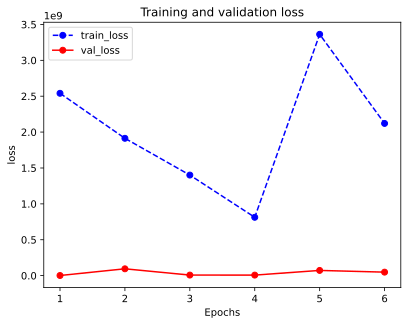

In [20]:
plot_metric(dfhistory,"loss")

![](https://tva1.sinaimg.cn/large/e6c9d24egy1h48rhp9jpqj20ej0acwer.jpg)

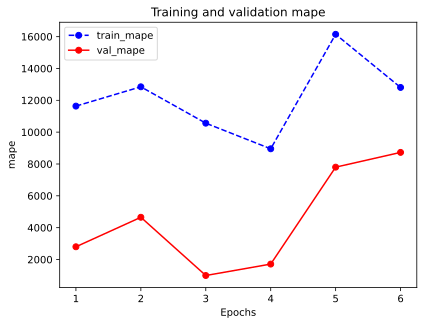

In [41]:
plot_metric(dfhistory,"mape")

![](https://tva1.sinaimg.cn/large/e6c9d24egy1h48rj15ctvj20f70ag3yv.jpg)

### 五，使用模型

此处我们使用模型预测疫情结束时间，即 新增确诊病例为0 的时间。

In [30]:
#使用dfresult记录现有数据以及此后预测的疫情数据
dfresult = dfdiff[["MQLL1","KQLL1","GDWD1", "YDWD1", "RZ", "RSZ1"]].copy()
dfresult.tail()

,MQLL1,KQLL1,GDWD1,YDWD1,RZ,RSZ1
412339,0.0,0.0,-3.321,-0.672,-17.124001,0.0
412340,0.0,0.0,-2.503,-0.269,-0.107000,0.0
412341,0.0,0.0,-0.888,0.000,6.961000,0.0
412342,0.0,0.0,-1.430,0.000,8.254000,0.0
412343,0.0,0.0,-2.343,0.000,4.853000,0.0


![](./data/1-4-日期3月10.png)

In [31]:
#预测此后1000天的新增走势,将其结果添加到dfresult中
for i in range(1000):
    arr_input = torch.unsqueeze(torch.from_numpy(dfresult.values[-38:,:]),axis=0)
    arr_predict = model.forward(arr_input)
    dfpredict = pd.DataFrame(
        torch.floor(arr_predict).data.numpy(),
        columns = dfresult.columns
    )
    dfresult = pd.concat([dfresult,dfpredict],ignore_index=True)

In [40]:
dfresult.to_csv("dfresult.csv")

In [34]:
# dfresult.query("confirmed_num==0").head()

# 第50天开始新增确诊降为0，第45天对应3月10日，也就是5天后，即预计3月15日新增确诊降为0
# 注：该预测偏乐观

![](./data/1-4-torch预测确诊.png)

In [35]:
# dfresult.query("cured_num==0").head()

# 第132天开始新增治愈降为0，第45天对应3月10日，也就是大概3个月后，即6月10日左右全部治愈。
# 注: 该预测偏悲观，并且存在问题，如果将每天新增治愈人数加起来，将超过累计确诊人数。

![](./data/1-4-torch预测治愈.png)

### 六，保存模型

模型保存在了trainer.checkpoint_callback.best_model_path路径。


In [36]:
print(trainer.checkpoint_callback.best_model_path)
print(trainer.checkpoint_callback.best_model_score)

/Users/zfwang/模型训练代码和数据/lightning_logs/version_0/checkpoints/epoch=2-step=77313.ckpt
tensor(993.0016)


In [37]:
#pytorch_lightning不仅保留了模型参数，还保存了模型结构，可以用LightModel重新加载
model_loaded = LightModel.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:262: UserWarning: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
  rank_zero_warn(


In [38]:
trainer.predict(model_loaded,dataloaders=dl_val)

/Users/zfwang/Applications/miniconda3/envs/3.10.9/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, predict_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting: 25771it [00:00, ?it/s]

[tensor([[0.0000e+00, 1.9979e+01, 0.0000e+00, 2.0356e-03, 2.5054e-02, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.9226e-03, 2.3057e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 3.6085e-03, 2.0310e-03, 0.0000e+00, 0.0000e+00],
         [1.9942e+03, 4.7495e+00, 0.0000e+00, 1.8816e-03, 3.0695e-01, 0.0000e+00],
         [2.3432e+02, 3.7010e+01, 0.0000e+00, 2.8986e-03, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0270e-03, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 6.6293e+00, 6.1965e-03, 1.8630e-03, 0.0000e+00, 0.0000e+00],
         [1.1617e+03, 0.0000e+00, 3.1617e-03, 1.8839e-03, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.8990e-03, 1.2626e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 6.6662e-03, 1.9404e-03, 2.5913e-01, 0.0000e+00],
         [1.2645e+03, 1.0737e+02, 7.3199e-03, 2.0480e-03, 0.0000e+00, 0.0000e+00],
         [1.7235e+02, 0.0000e+00, 0.0000e+00, 2.0366e-03, 0.0000e+00, 0.0000e+00],
    

```
[tensor([[1.4974e+03, 8.5825e+01, 2.3000e+01],
         [1.8469e+03, 6.7295e+01, 4.6768e+01],
         [2.0153e+03, 1.4337e+02, 4.3701e+01],
         [2.3063e+03, 1.5312e+02, 4.9068e+01],
         [2.7721e+03, 2.5358e+02, 4.9834e+01],
         [2.6352e+03, 2.5455e+02, 5.5968e+01],
         [2.2421e+03, 3.7744e+02, 5.5968e+01],
         [2.4147e+03, 4.9740e+02, 6.5935e+01],
         [1.8918e+03, 5.8420e+02, 6.8235e+01],
         [2.1208e+03, 6.1638e+02, 7.4368e+01],
         [1.7599e+03, 6.9733e+02, 8.2802e+01],
         [1.4374e+03, 7.2561e+02, 7.4368e+01],
         [1.0808e+04, 1.1421e+03, 1.9474e+02],
         [2.8870e+03, 7.9193e+02, 9.9669e+00],
         [1.8840e+03, 1.3391e+03, 1.0964e+02],
         [1.4324e+03, 1.2903e+03, 1.0887e+02],
         [1.4610e+03, 1.3898e+03, 8.0502e+01],
         [1.3468e+03, 1.6658e+03, 7.5135e+01],
         [1.2477e+03, 1.7789e+03, 1.0427e+02],
         [2.7895e+02, 1.7353e+03, 8.7424e+01],
         [6.3425e+02, 2.0573e+03, 9.0511e+01],
         [5.8716e+02, 2.3365e+03, 8.3624e+01],
         [4.6230e+02, 2.1747e+03, 7.4431e+01],
         [1.5267e+02, 1.8011e+03, 1.1512e+02],
         [3.6241e+02, 2.5261e+03, 5.4495e+01],
         [2.8963e+02, 2.3633e+03, 3.9916e+01],
         [3.0889e+02, 2.6834e+03, 2.2262e+01],
         [2.3327e+02, 3.5342e+03, 3.3777e+01],
         [3.0461e+02, 2.8151e+03, 3.6080e+01],
         [4.0876e+02, 2.5594e+03, 2.6868e+01],
         [1.4410e+02, 2.7683e+03, 3.2242e+01],
         [8.9172e+01, 2.6756e+03, 2.3798e+01],
         [8.4892e+01, 2.5877e+03, 2.9171e+01],
         [9.9159e+01, 2.1360e+03, 2.3798e+01],
         [1.0201e+02, 1.6403e+03, 2.3030e+01],
         [7.0624e+01, 1.6373e+03, 2.1495e+01],
         [3.1389e+01, 1.6208e+03, 2.0727e+01],
         [2.8535e+01, 1.4978e+03, 1.6889e+01]])]
```

**如果本书对你有所帮助，想鼓励一下作者，记得给本项目加一颗星星star⭐️，并分享给你的朋友们喔😊!** 

如果对本书内容理解上有需要进一步和作者交流的地方，欢迎在公众号"算法美食屋"下留言。作者时间和精力有限，会酌情予以回复。

也可以在公众号后台回复关键字：**加群**，加入读者交流群和大家讨论。

![算法美食屋logo.png](https://tva1.sinaimg.cn/large/e6c9d24egy1h41m2zugguj20k00b9q46.jpg)